# Libraries

In [2]:
import cdsapi
import pandas as pd
import xarray as xr
from netCDF4 import Dataset
import shutil
import dataframe_image as dfi
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.gofplots import qqplot

In [3]:
# To check if CDS is working or not
print("CDS API client installed and working!")

CDS API client installed and working!


### Import data from copernicus cams-global-reanalysis-eac4 dataset

In [2]:
# Initialize CDS API
c = cdsapi.Client()

# Milan area [North, West, South, East]
area_milan = [45.55, 8.95, 45.35, 9.30]

date_range = '2018-01-01/2024-12-31'
times = ['00:00','03:00','06:00','09:00','12:00','15:00','18:00','21:00']

# 1) near-surface (model level 60)
chemistry = {
    'no2': 'nitrogen_dioxide',
    'co': 'carbon_monoxide',
    'o3': 'ozone',
    'pm10': 'particulate_matter_10um',
}

for short_name, variable in chemistry.items():
    print(f"\n⏳ Downloading {variable} for Milan...")
    c.retrieve(
        'cams-global-reanalysis-eac4',
        {
            'variable': variable,
            'type': 'analysis',
            'date': date_range,
            'time': times,
            'model_level': '60',         
            'format': 'netcdf',
            'area': area_milan,
        },
        f'milan_{short_name}_2018_2024.nc'
    )
    print(f"Saved as milan_{short_name}_2018_2024.nc")

# 2) 2 m temperature (single level; no model_level)
print(f"\nDownloading 2m_temperature for Milan...")
c.retrieve(
    'cams-global-reanalysis-eac4',
    {
        'variable': '2m_temperature',
        'type': 'analysis',
        'date': date_range,
        'time': times,
        'format': 'netcdf',
        'area': area_milan,
    },
    'milan_temp_2018_2024.nc'
)
print("Saved as milan_temp_2018_2024.nc")

2025-08-20 20:03:28,511 INFO [2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.



⏳ Downloading nitrogen_dioxide for Milan...


2025-08-20 20:03:28,819 INFO Request ID is 1338d99c-d3af-4be3-bd9c-73bcee9f62bd
2025-08-20 20:03:29,024 INFO status has been updated to accepted
2025-08-20 20:03:50,899 INFO status has been updated to running
2025-08-20 20:21:56,613 INFO status has been updated to successful


e0b503dda9010bd94ae8fe68cb99522a.nc:   0%|          | 0.00/253k [00:00<?, ?B/s]

✅ Saved as milan_no2_2018_2024.nc

⏳ Downloading carbon_monoxide for Milan...


...

bb79c1bd11a50b078b96169dad658f90.nc:   0%|          | 0.00/248k [00:00<?, ?B/s]

✅ Saved as milan_pm10_2018_2024.nc

⏳ Downloading 2m_temperature for Milan...


2025-08-20 21:27:44,054 INFO Request ID is d2e0eba9-5aaa-49d6-ab29-9cb1467d6c50
2025-08-20 21:27:44,140 INFO status has been updated to accepted
2025-08-20 21:27:57,826 INFO status has been updated to running
Recovering from connection error [('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))], attempt 1 of 500
Retrying in 120 seconds
2025-08-20 21:50:01,526 INFO status has been updated to successful


630a36eae006d00cc5b50199b3110d31.nc:   0%|          | 0.00/227k [00:00<?, ?B/s]

✅ Saved as milan_temp_2018_2024.nc


In [ ]:
request = {
    'variable': variable,
    'date': '2018-01-01/2024-12-31',
    'time': ['00:00', '03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00'],
    'format': 'netcdf',
    'type': 'analysis',
    'area': [45.7, 8.7, 45.2, 9.5]
}

print("Request being sent:")
print(request)

c.retrieve('cams-global-reanalysis-eac4', request, f'milan_{short_name}_2018_2024.nc')

### Check files and their terget variables

In [29]:
expected_variables = {
    'milan_no2_2018_2024.nc': 'no2',
    'milan_pm10_2018_2024.nc': 'pm10',
    'milan_co_2018_2024.nc': 'co',
    'milan_o3_2018_2024.nc': 'go3',
    'milan_temp_2018_2024.nc': 't2m'
}

# Check each file
for filename, expected_var in expected_variables.items():
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    try:
        with Dataset(filename, 'r') as ds:
            available_vars = list(ds.variables.keys())
            print(f"\n File: {filename}")
            print(f" Available variables: {available_vars}")

            # Check if expected variable is in the file
            if expected_var in available_vars:
                print(f" Variable '{expected_var}' is present.")
            else:
                print(f" Variable '{expected_var}' is MISSING!")
    except Exception as e:
        print(f" Error reading {filename}: {e}")


 File: milan_no2_2018_2024.nc
 Available variables: ['valid_time', 'model_level', 'latitude', 'longitude', 'no2']
 Variable 'no2' is present.

 File: milan_pm10_2018_2024.nc
 Available variables: ['valid_time', 'latitude', 'longitude', 'pm10']
 Variable 'pm10' is present.

 File: milan_co_2018_2024.nc
 Available variables: ['valid_time', 'model_level', 'latitude', 'longitude', 'co']
 Variable 'co' is present.

 File: milan_o3_2018_2024.nc
 Available variables: ['valid_time', 'model_level', 'latitude', 'longitude', 'go3']
 Variable 'go3' is present.

 File: milan_temp_2018_2024.nc
 Available variables: ['valid_time', 'latitude', 'longitude', 't2m']
 Variable 't2m' is present.


### Load all dataset and check the times adn length of all the datasets

In [1]:
# Load all datasets
temp = xr.open_dataset('milan_temp_2018_2024.nc')
pm10 = xr.open_dataset('milan_pm10_2018_2024.nc')
no2 = xr.open_dataset('milan_no2_2018_2024.nc')
co = xr.open_dataset('milan_co_2018_2024.nc')
o3 = xr.open_dataset('milan_o3_2018_2024.nc')

# Print time lengths and ranges
print(" Temperature (t2m):")
print(f"Length: {len(temp['valid_time'])}")
print(f"Start: {temp['valid_time'].values[0]}, End: {temp['valid_time'].values[-1]}\n")

print(" PM10 (point):")
print(f"Length: {len(pm10['valid_time'])}")
print(f"Start: {pm10['valid_time'].values[0]}, End: {pm10['valid_time'].values[-1]}\n")

print(" NO2:")
print(f"Length: {len(no2['valid_time'])}")
print(f"Start: {no2['valid_time'].values[0]}, End: {no2['valid_time'].values[-1]}\n")

print(" CO:")
print(f"Length: {len(co['valid_time'])}")
print(f"Start: {co['valid_time'].values[0]}, End: {co['valid_time'].values[-1]}\n")

print(" O3:")
print(f"Length: {len(o3['valid_time'])}")
print(f"Start: {o3['valid_time'].values[0]}, End: {o3['valid_time'].values[-1]}\n")

 Temperature (t2m):
Length: 20456
Start: 2018-01-01T00:00:00.000000000, End: 2024-12-31T21:00:00.000000000

 PM10 (point):
Length: 20456
Start: 2018-01-01T00:00:00.000000000, End: 2024-12-31T21:00:00.000000000

 NO2:
Length: 20456
Start: 2018-01-01T00:00:00.000000000, End: 2024-12-31T21:00:00.000000000

 CO:
Length: 20456
Start: 2018-01-01T00:00:00.000000000, End: 2024-12-31T21:00:00.000000000

 O3:
Length: 20456
Start: 2018-01-01T00:00:00.000000000, End: 2024-12-31T21:00:00.000000000



In [2]:
# Input and output file names
input_file = 'milan_o3_2018_2024.nc'
output_file = 'milan_o3_renamed.nc'

# Copy the original file to keep it safe
shutil.copy(input_file, output_file)

# Open the copied file in append mode
with Dataset(output_file, 'a') as ds:
    if 'go3' in ds.variables:
        # Rename 'go3' to 'o3'
        ds.renameVariable('go3', 'o3')
        print(" Successfully renamed 'go3' to 'o3' in the new file.")
    else:
        print(" 'go3' not found, rename aborted.")

 Successfully renamed 'go3' to 'o3' in the new file.


In [8]:
ls

 Volume in drive C is Windows-SSD
 Volume Serial Number is 281D-D955

 Directory of C:\Users\fazlu\OneDrive\Desktop\projects\internship

11/07/2025  04:28 PM    <DIR>          .
10/31/2025  03:43 PM    <DIR>          ..
08/03/2025  04:45 PM    <DIR>          .ipynb_checkpoints
08/20/2025  08:46 PM         2,187,646 dhaka.ipynb
08/20/2025  07:42 PM           258,184 dhaka_co_2018_2024.nc
08/20/2025  07:22 PM           259,724 dhaka_no2_2018_2024.nc
08/20/2025  08:05 PM           260,985 dhaka_o3_2018_2024.nc
08/20/2025  08:23 PM           252,217 dhaka_pm10_2018_2024.nc
08/20/2025  08:42 PM           231,415 dhaka_temp_2018_2024.nc
11/07/2025  04:28 PM         2,393,542 Final.ipynb
11/07/2025  03:42 PM         1,761,859 internship.docx
11/07/2025  04:13 PM           403,578 internship.pdf
10/30/2025  07:46 AM         1,748,457 milan_air_quality_2018_2024.csv
08/20/2025  07:42 PM           256,132 milan_co_2018_2024.nc
08/20/2025  07:21 PM           259,163 milan_no2_2018_2024.nc
08/20/2

In [9]:
files = {
    'temp': 'milan_temp_2018_2024.nc',
    'pm10': 'milan_pm10_2018_2024.nc',
    'no2': 'milan_no2_2018_2024.nc',
    'co': 'milan_co_2018_2024.nc',
    'o3': 'milan_o3_renamed.nc'
}

for name, filepath in files.items():
    ds = xr.open_dataset(filepath)
    time_var = 'valid_time' if 'valid_time' in ds.variables else None
    if time_var:
        times = ds[time_var].values
        print(f"{name.upper()} dataset:")
        print(f"  Length: {len(times)}")
        print(f"  Start: {times[0]}")
        print(f"  End:   {times[-1]}")
    else:
        print(f"{name.upper()} dataset does not have 'valid_time' variable.")
    print('-' * 30)

TEMP dataset:
  Length: 20456
  Start: 2018-01-01T00:00:00.000000000
  End:   2024-12-31T21:00:00.000000000
------------------------------
PM10 dataset:
  Length: 20456
  Start: 2018-01-01T00:00:00.000000000
  End:   2024-12-31T21:00:00.000000000
------------------------------
NO2 dataset:
  Length: 20456
  Start: 2018-01-01T00:00:00.000000000
  End:   2024-12-31T21:00:00.000000000
------------------------------
CO dataset:
  Length: 20456
  Start: 2018-01-01T00:00:00.000000000
  End:   2024-12-31T21:00:00.000000000
------------------------------
O3 dataset:
  Length: 20456
  Start: 2018-01-01T00:00:00.000000000
  End:   2024-12-31T21:00:00.000000000
------------------------------


### Checking location (Milan)

In [10]:
import xarray as xr

# opening one file
ds = xr.open_dataset('milan_no2_2018_2024.nc')
print(ds)

<xarray.Dataset>
Dimensions:      (valid_time: 20456, model_level: 1, latitude: 1, longitude: 1)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 2018-01-01 ... 2024-12-31T21:00:00
  * model_level  (model_level) float64 60.0
  * latitude     (latitude) float64 45.35
  * longitude    (longitude) float64 8.95
Data variables:
    no2          (valid_time, model_level, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-20T18:20 GRIB to CDM+CF via cfgrib-0.9.1...


### Convert all the dataset to pandas series and concatenate them into one dataframe for fututre analysis

In [13]:
# Load datasets
temp_ds = xr.open_dataset('milan_temp_2018_2024.nc')
pm10_ds = xr.open_dataset('milan_pm10_2018_2024.nc')
no2_ds = xr.open_dataset('milan_no2_2018_2024.nc')
co_ds = xr.open_dataset('milan_co_2018_2024.nc')
o3_ds = xr.open_dataset('milan_o3_renamed.nc')

# Extract variables at a specific location
temp = temp_ds['t2m'].isel(latitude=0, longitude=0)
pm10 = pm10_ds['pm10'].isel(latitude=0, longitude=0)
no2 = no2_ds['no2'].isel(model_level=0, latitude=0, longitude=0)
co = co_ds['co'].isel(model_level=0, latitude=0, longitude=0)
o3 = o3_ds['o3'].isel(model_level=0, latitude=0, longitude=0)

# Convert to pandas Series
temp_series = temp.to_series()
pm10_series = pm10.to_series()
no2_series = no2.to_series()
co_series = co.to_series()
o3_series = o3.to_series()

# Combine into DataFrame
df = pd.concat([
    temp_series.rename('temp_2m'),
    pm10_series.rename('pm10'),
    no2_series.rename('no2'),
    co_series.rename('co'),
    o3_series.rename('o3')
], axis=1)

df.index.name = 'datetime'

# Save once to CSV
df.to_csv('milan_air_quality_2018_2024.csv')
print("CSV saved successfully.")

CSV saved successfully.


### load the preprocessed CSV

In [12]:
df = pd.read_csv('milan_air_quality_2018_2024.csv', parse_dates=['datetime'], index_col='datetime')
df.head()

,temp_2m,pm10,no2,co,o3
datetime,,,,,
2018-01-01 00:00:00,277.04053,3.758047e-08,3.046469e-08,4.602559e-07,2.390653e-09
2018-01-01 03:00:00,276.43700,3.830286e-08,3.297369e-08,4.647381e-07,8.534125e-10
2018-01-01 06:00:00,275.89648,4.009183e-08,3.261977e-08,4.915332e-07,6.464088e-10
2018-01-01 09:00:00,276.24023,4.068525e-08,2.250764e-08,5.022816e-07,9.117302e-09
2018-01-01 12:00:00,278.28710,1.452933e-08,1.324147e-08,3.761426e-07,2.617308e-08


### Check start and end date, missing values and basic statistics

In [21]:
print("Data time range:")
print(f"Start: {df.index.min()}")
print(f"End: {df.index.max()}")

print("\nMissing data count per variable:")
print(df.isnull().sum())

print("\nBasic stats:")
print(df.describe())

Data time range:
Start: 2018-01-01 00:00:00
End: 2024-12-31 21:00:00

Missing data count per variable:
temp_2m    0
pm10       0
no2        0
co         0
o3         0
dtype: int64

Basic stats:
            temp_2m          pm10           no2            co            o3
count  20456.000000  2.045600e+04  2.045600e+04  2.045600e+04  2.045600e+04
mean     286.285437  2.348090e-08  1.558146e-08  2.163398e-07  3.927708e-08
std        8.163120  1.230254e-08  1.046040e-08  9.121735e-08  3.260468e-08
min      264.675540  0.000000e+00  9.999999e-15  8.150248e-08  9.999999e-15
25%      279.560057  1.564831e-08  4.934453e-09  1.467603e-07  1.018757e-08
50%      286.052490  2.229806e-08  1.587362e-08  1.912003e-07  3.061304e-08
75%      292.692747  2.953838e-08  2.432845e-08  2.645874e-07  6.498688e-08
max      309.891850  2.370373e-07  6.448110e-08  6.770835e-07  1.331969e-07


In [23]:
# A copy of df and convert temperature
df_1 = df.copy()
df_1 = df_1.rename(columns={
    'temp_2m': 'Temperature (°C)',
    'pm10': 'PM10 (kg/m³)',
    'no2': 'NO₂ (kg/m³)',
    'co': 'CO (kg/m³)',
    'o3': 'O₃ (kg/m³)'
})

df_1['Temperature (°C)'] = df_1['Temperature (°C)'] - 273.15

In [24]:
# top 10 data
df_head = df_1.head(10)
df_head.index = df_head.index.strftime('%Y-%m-%d %H:%M')
df_head

,Temperature (°C),PM10 (kg/m³),NO₂ (kg/m³),CO (kg/m³),O₃ (kg/m³)
datetime,,,,,
2018-01-01 00:00,3.89053,3.758047e-08,3.046469e-08,4.602559e-07,2.390653e-09
2018-01-01 03:00,3.28700,3.830286e-08,3.297369e-08,4.647381e-07,8.534125e-10
2018-01-01 06:00,2.74648,4.009183e-08,3.261977e-08,4.915332e-07,6.464088e-10
2018-01-01 09:00,3.09023,4.068525e-08,2.250764e-08,5.022816e-07,9.117302e-09
2018-01-01 12:00,5.13710,1.452933e-08,1.324147e-08,3.761426e-07,2.617308e-08
2018-01-01 15:00,6.66274,1.941397e-08,1.764917e-08,3.652007e-07,1.966442e-08
2018-01-01 18:00,2.58486,3.837509e-08,2.582032e-08,4.630594e-07,1.565836e-09
2018-01-01 21:00,2.67617,4.619526e-08,2.648803e-08,5.266879e-07,1.450784e-09
2018-01-02 00:00,1.82020,3.614494e-08,2.343989e-08,4.618553e-07,7.279799e-09


In [25]:
pollutants = ['PM10 (kg/m³)', 'NO₂ (kg/m³)', 'CO (kg/m³)', 'O₃ (kg/m³)']

# Convert each pollutant from kg/m³ to μg/m³
for col in pollutants:
    if col in df_1.columns:
        df_1[col.replace('kg/m³', 'μg/m³')] = df_1[col] * 1e9  # Multiply by 1 billion

# Optional: Drop the original kg/m³ columns
df_1 = df_1.drop(columns=pollutants)

# columns are in μg/m³
print(df_1.head())

                     Temperature (°C)  PM10 (μg/m³)  NO₂ (μg/m³)  CO (μg/m³)  \
datetime                                                                       
2018-01-01 00:00:00           3.89053     37.580474    30.464687   460.25593   
2018-01-01 03:00:00           3.28700     38.302860    32.973690   464.73812   
2018-01-01 06:00:00           2.74648     40.091827    32.619766   491.53317   
2018-01-01 09:00:00           3.09023     40.685254    22.507637   502.28164   
2018-01-01 12:00:00           5.13710     14.529334    13.241467   376.14260   

                     O₃ (μg/m³)  
datetime                         
2018-01-01 00:00:00    2.390653  
2018-01-01 03:00:00    0.853413  
2018-01-01 06:00:00    0.646409  
2018-01-01 09:00:00    9.117302  
2018-01-01 12:00:00   26.173085  


### Plot

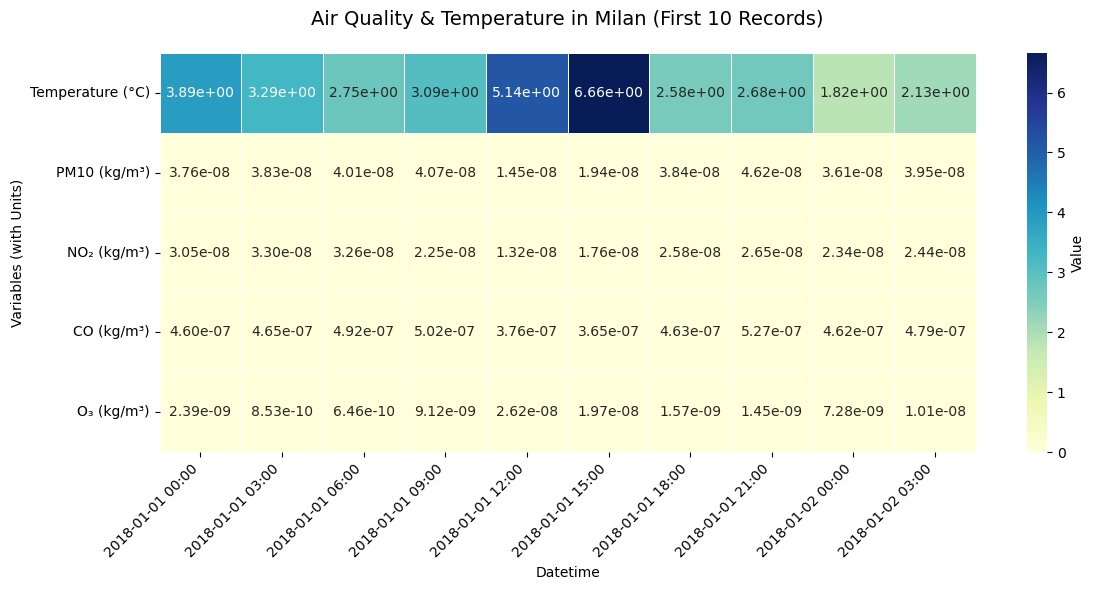

In [26]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_head.T, cmap="YlGnBu", annot=True, fmt=".2e", linewidths=0.5,
            cbar_kws={"label": "Value"})

plt.title("Air Quality & Temperature in Milan (First 10 Records)", fontsize=14, pad=20)
plt.xlabel("Datetime")
plt.ylabel("Variables (with Units)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()


In [27]:
df_1.describe()

,Temperature (°C),PM10 (μg/m³),NO₂ (μg/m³),CO (μg/m³),O₃ (μg/m³)
count,20456.000000,20456.000000,20456.000000,20456.000000,20456.000000
mean,13.135437,23.480896,15.581464,216.339783,39.277077
std,8.163120,12.302545,10.460400,91.217354,32.604679
min,-8.474460,0.000000,0.000010,81.502480,0.000010
25%,6.410058,15.648312,4.934452,146.760263,10.187573
50%,12.902490,22.298060,15.873619,191.200325,30.613041
75%,19.542748,29.538382,24.328454,264.587415,64.986879
max,36.741850,237.037280,64.481100,677.083450,133.196920


In [28]:
print(df.columns)

Index(['temp_2m', 'pm10', 'no2', 'co', 'o3'], dtype='object')


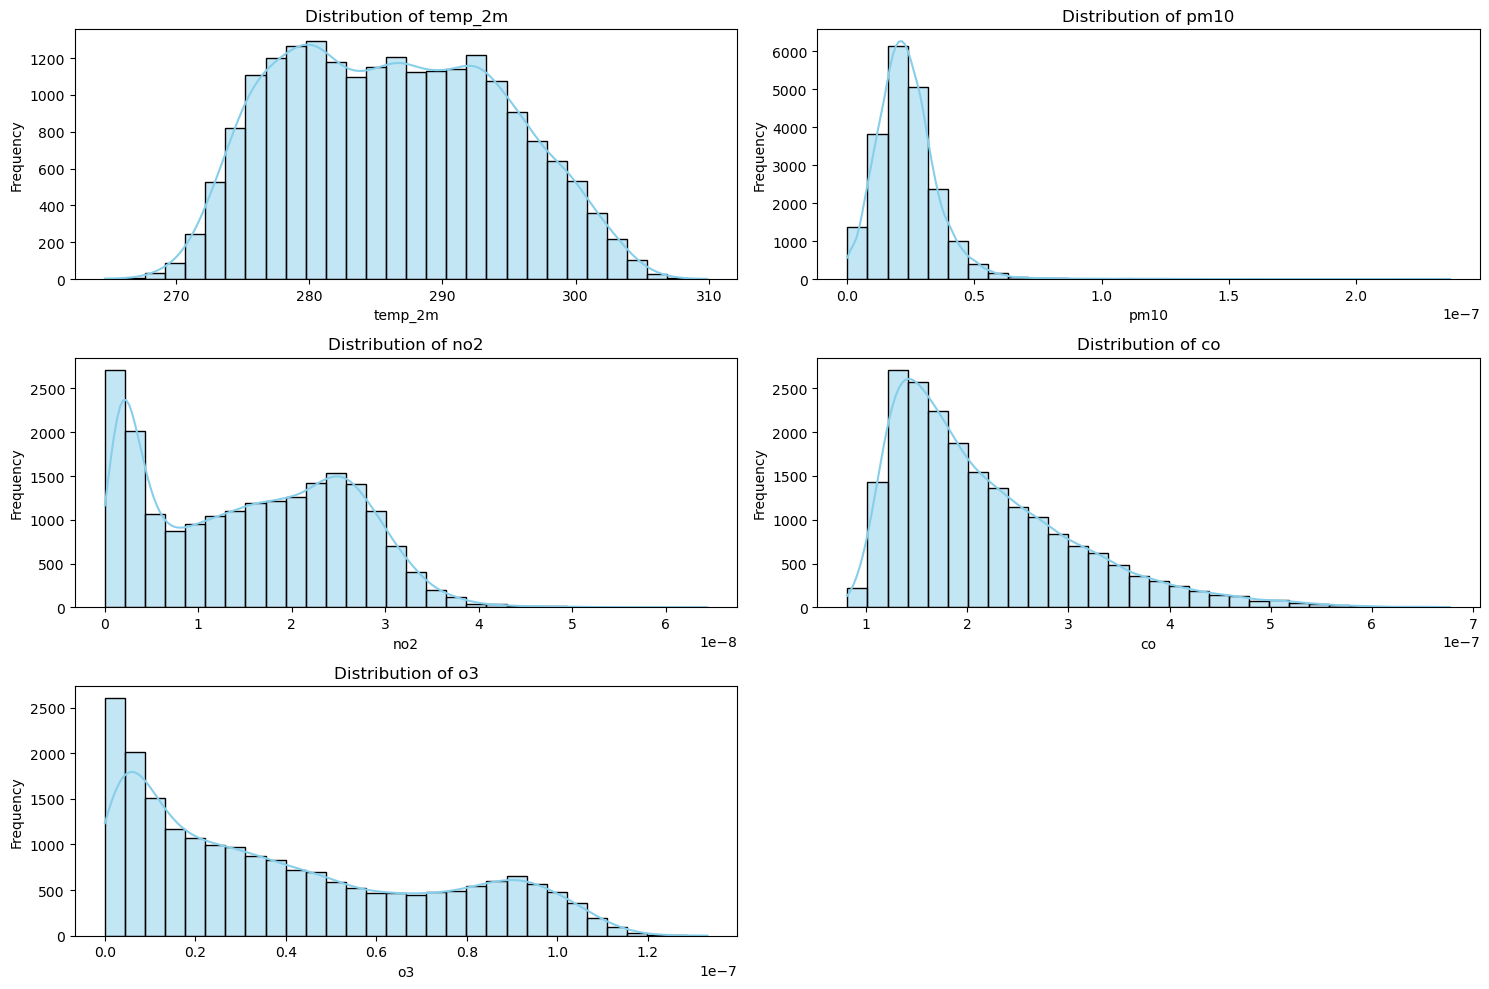

In [29]:
# List of numeric columns 
numeric_cols = ['temp_2m', 'pm10', 'no2', 'co', 'o3']

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)  
    sns.histplot(df[col].dropna(), kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

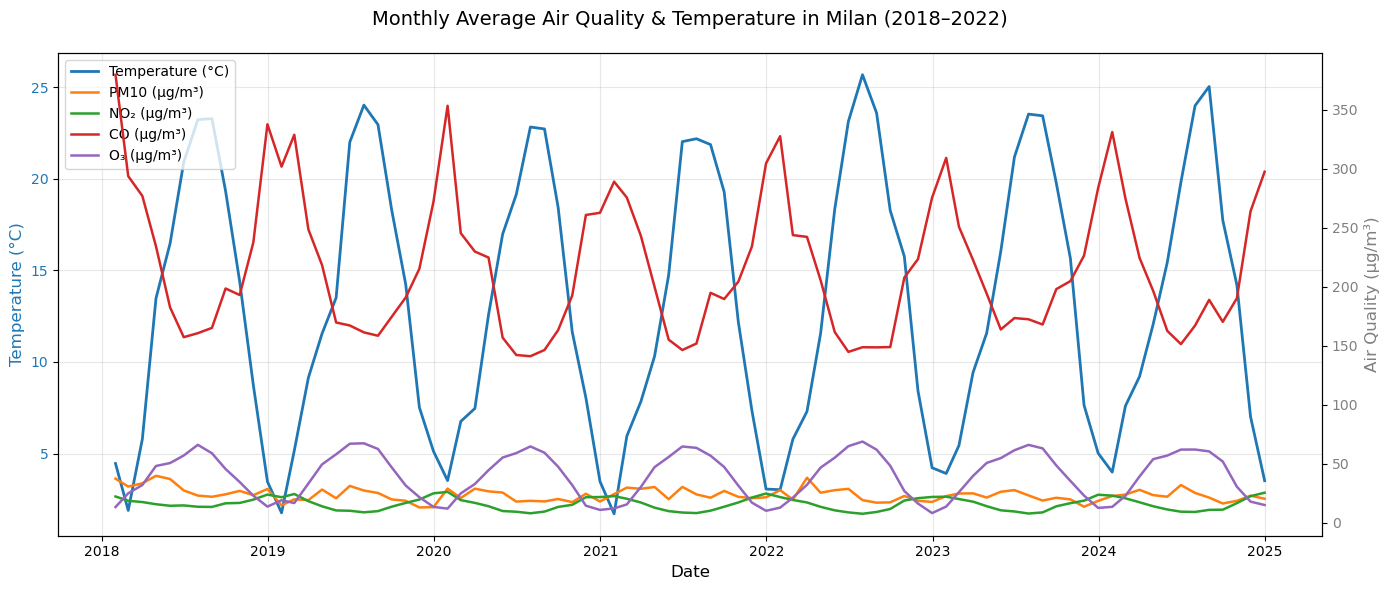

In [30]:
# Resample the data to get monthly averages
df_resampled = df_1.resample('M').mean()

# Create a figure and a primary axis for temperature
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot temperature on the primary y-axis
color_temp = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color=color_temp, fontsize=12)
ax1.plot(df_resampled.index, df_resampled['Temperature (°C)'], color=color_temp, label='Temperature (°C)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_temp)
ax1.grid(True, alpha=0.3)

# Instantiate a second axis that shares the same x-axis
ax2 = ax1.twinx()

# Define air quality pollutants (now in μg/m³)
pollutants = ['PM10 (μg/m³)', 'NO₂ (μg/m³)', 'CO (μg/m³)', 'O₃ (μg/m³)']
colors = ['tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# Plot each air quality indicator
for col, color in zip(pollutants, colors):
    ax2.plot(df_resampled.index, df_resampled[col], color=color, label=col, linewidth=1.8)

# Set ylabel for air quality (common for all pollutants)
ax2.set_ylabel('Air Quality (μg/m³)', color='gray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='gray')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Title and layout
plt.title("Monthly Average Air Quality & Temperature in Milan (2018–2022)", fontsize=14, pad=20)
fig.tight_layout()

# Show the plot
plt.show()

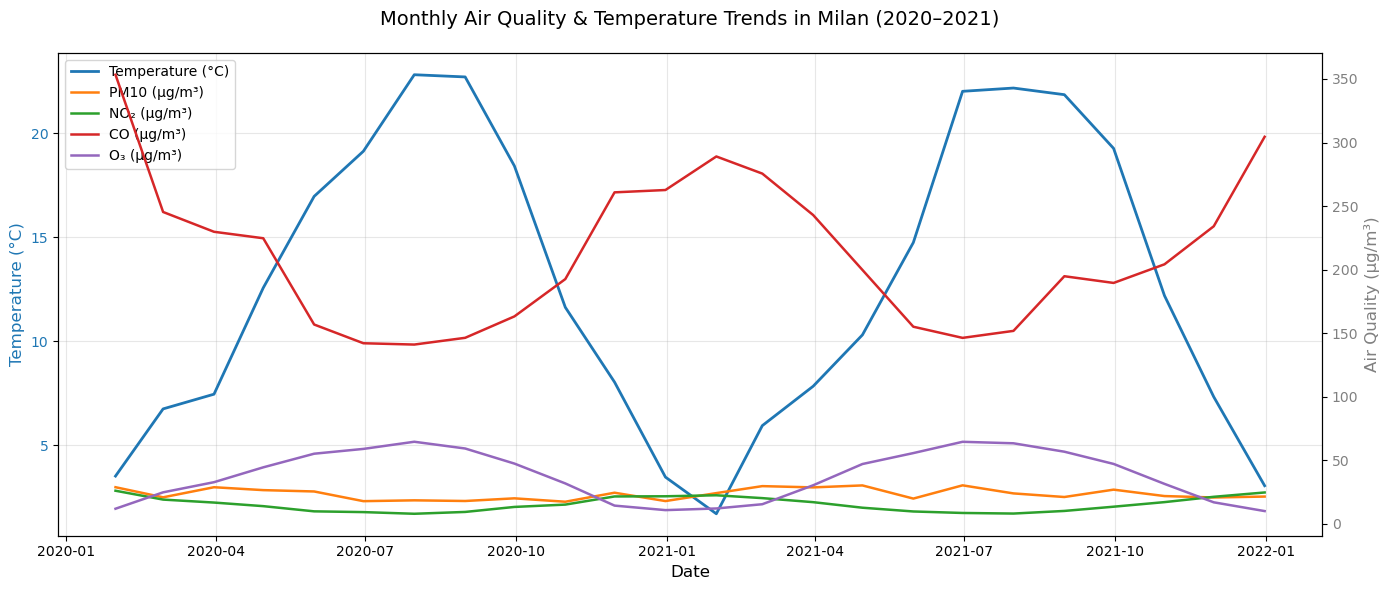

In [31]:
# Select data for a specific period (e.g., 2020–2021)
df_year = df_1.loc['2020-01-01':'2021-12-31']

# Resample the data to get monthly averages
df_resampled = df_year.resample('M').mean()

# Create a figure and a primary axis for temperature
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot temperature on the primary y-axis
color_temp = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color=color_temp, fontsize=12)
ax1.plot(df_resampled.index, df_resampled['Temperature (°C)'], color=color_temp, label='Temperature (°C)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_temp)
ax1.grid(True, alpha=0.3)

# Instantiate a second axis for pollutants
ax2 = ax1.twinx()

# Define air quality pollutants (in μg/m³)
pollutants = ['PM10 (μg/m³)', 'NO₂ (μg/m³)', 'CO (μg/m³)', 'O₃ (μg/m³)']
colors = ['tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# Plot each pollutant
for col, color in zip(pollutants, colors):
    ax2.plot(df_resampled.index, df_resampled[col], color=color, label=col, linewidth=1.8)

# Set ylabel for air quality
ax2.set_ylabel('Air Quality (μg/m³)', color='gray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='gray')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Title and layout
plt.title("Monthly Air Quality & Temperature Trends in Milan (2020–2021)", fontsize=14, pad=20)
fig.tight_layout()

# Show the plot
plt.show()

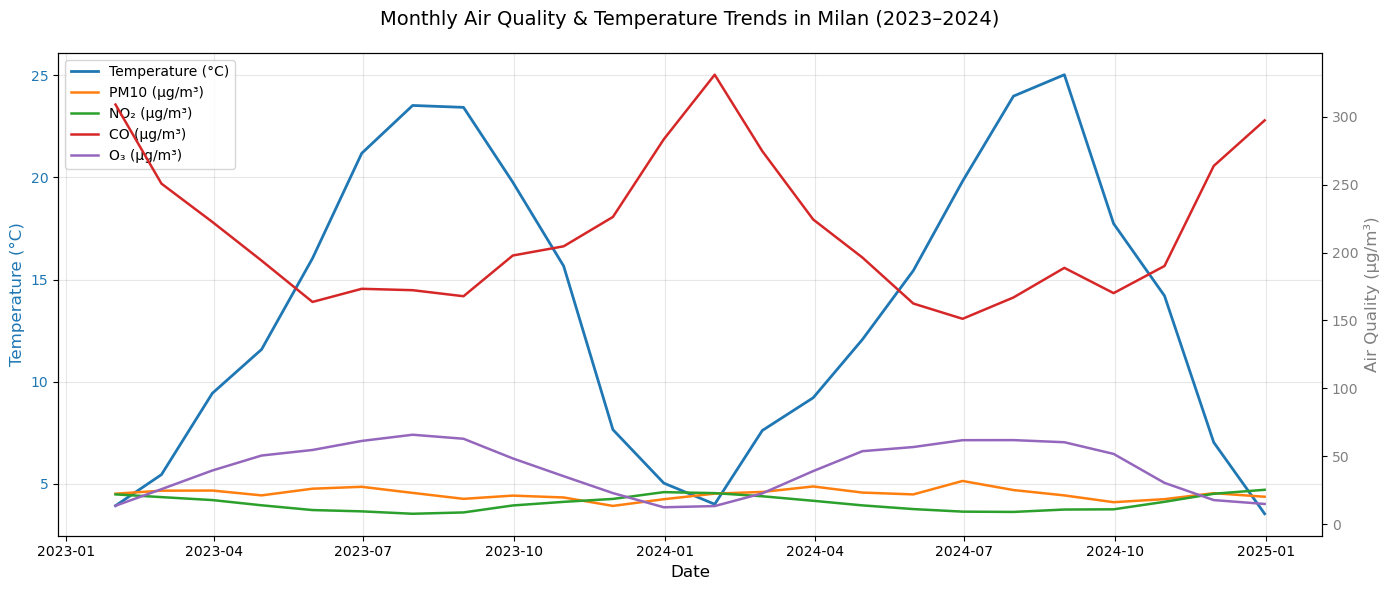

In [34]:
# Select data for a specific period (e.g., 2020–2021)
df_year = df_1.loc['2023-01-01':'2024-12-31']

# Resample the data to get monthly averages
df_resampled = df_year.resample('M').mean()

# Create a figure and a primary axis for temperature
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot temperature on the primary y-axis
color_temp = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color=color_temp, fontsize=12)
ax1.plot(df_resampled.index, df_resampled['Temperature (°C)'], color=color_temp, label='Temperature (°C)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_temp)
ax1.grid(True, alpha=0.3)

# Instantiate a second axis for pollutants
ax2 = ax1.twinx()

# Define air quality pollutants (in μg/m³)
pollutants = ['PM10 (μg/m³)', 'NO₂ (μg/m³)', 'CO (μg/m³)', 'O₃ (μg/m³)']
colors = ['tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# Plot each pollutant
for col, color in zip(pollutants, colors):
    ax2.plot(df_resampled.index, df_resampled[col], color=color, label=col, linewidth=1.8)

# Set ylabel for air quality
ax2.set_ylabel('Air Quality (μg/m³)', color='gray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='gray')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Title and layout
plt.title("Monthly Air Quality & Temperature Trends in Milan (2023–2024)", fontsize=14, pad=20)
fig.tight_layout()

# Show the plot
plt.show()

In [16]:
print(df_1.dtypes)
print(df_1.isnull().sum())

Temperature (°C)    float64
PM10 (μg/m³)        float64
NO₂ (μg/m³)         float64
CO (μg/m³)          float64
O₃ (μg/m³)          float64
dtype: object
Temperature (°C)    0
PM10 (μg/m³)        0
NO₂ (μg/m³)         0
CO (μg/m³)          0
O₃ (μg/m³)          0
dtype: int64


C:\Users\fazlu\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


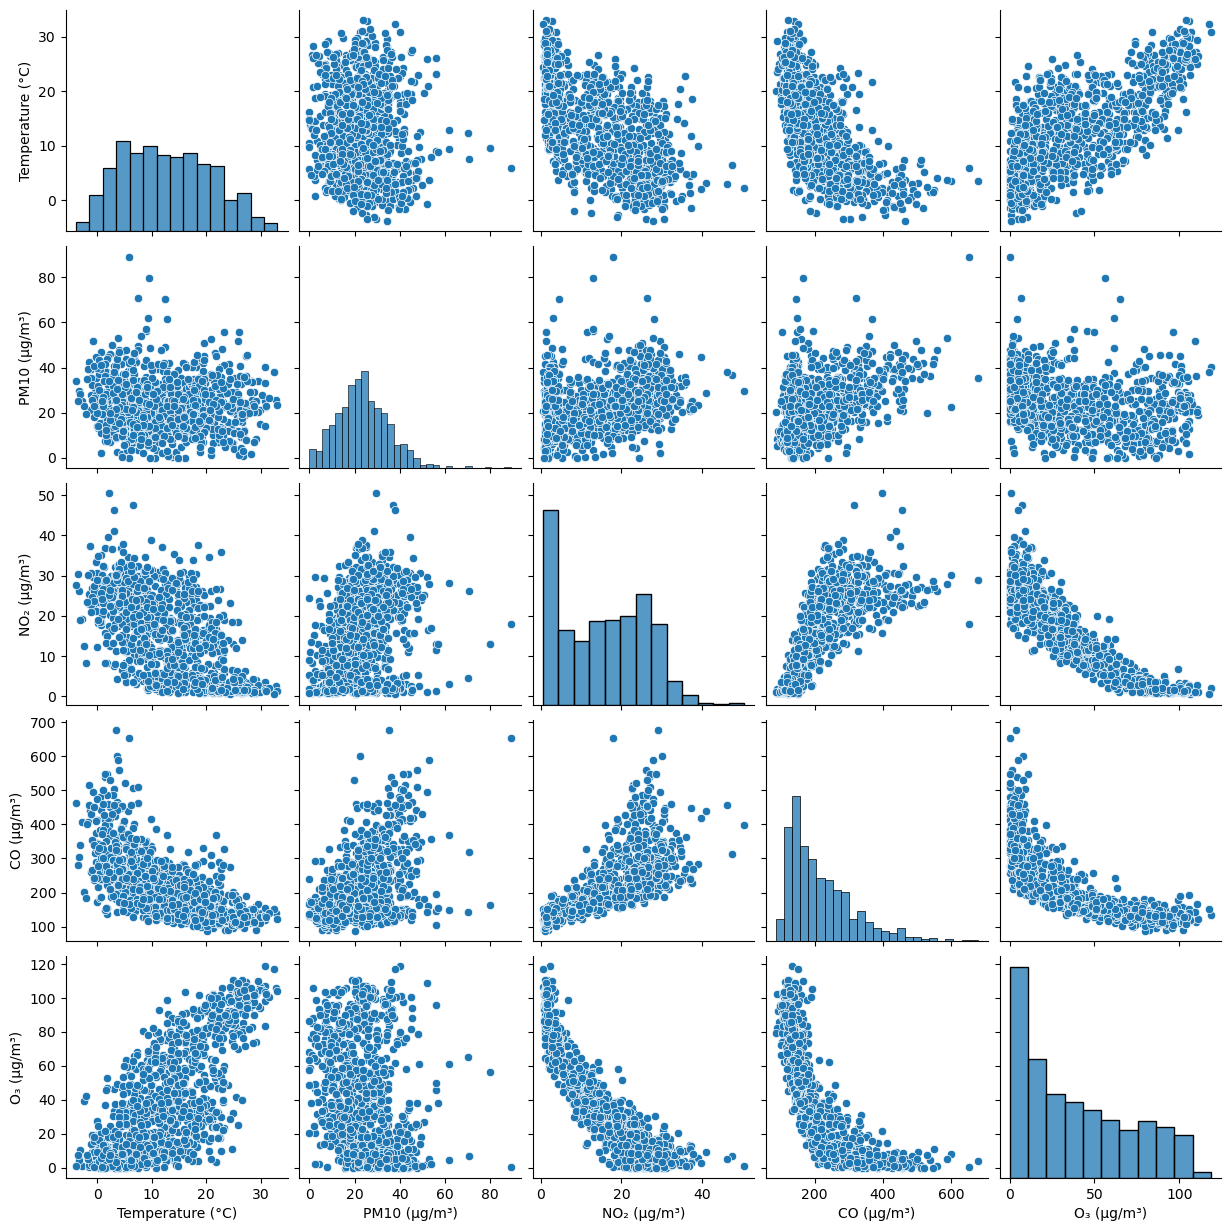

In [17]:
sns.pairplot(df_1.sample(1000))  
plt.show()

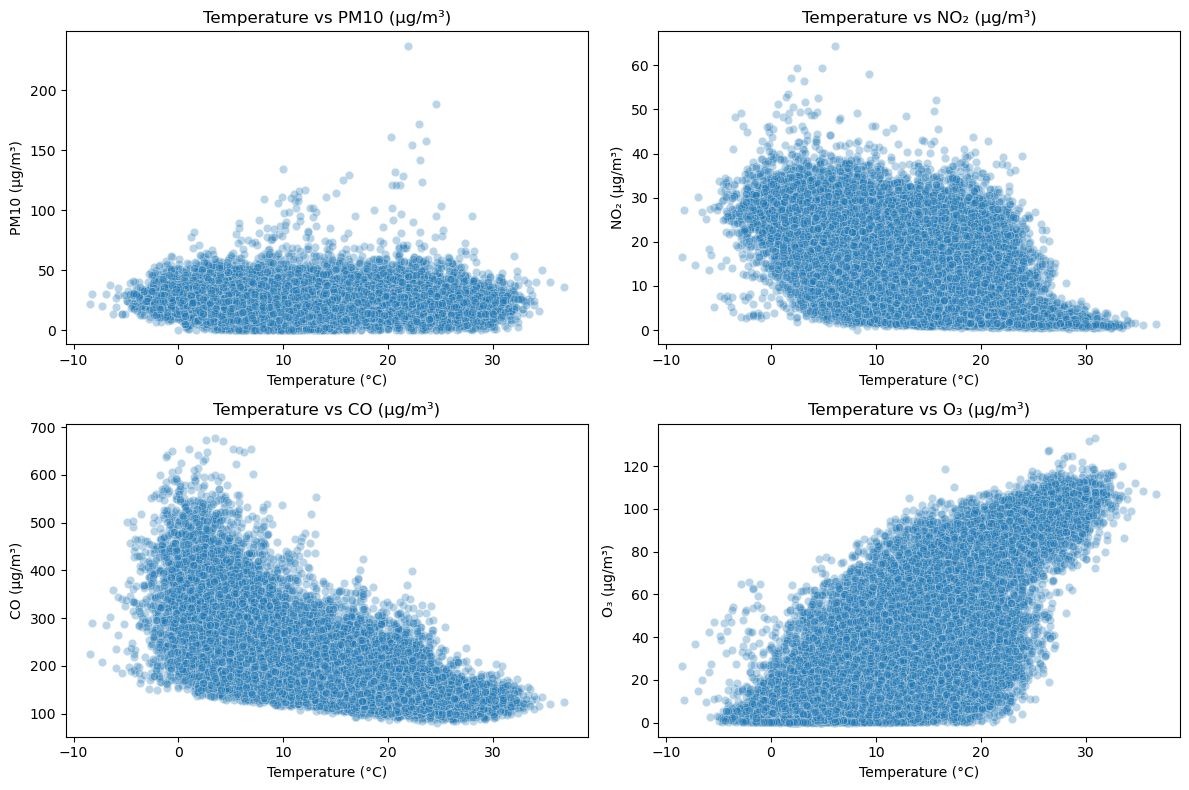

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
pollutants = ['PM10 (μg/m³)', 'NO₂ (μg/m³)', 'CO (μg/m³)', 'O₃ (μg/m³)']

for i, ax in enumerate(axs.flat):
    sns.scatterplot(x='Temperature (°C)', y=pollutants[i], data=df_1, ax=ax, alpha=0.3)
    ax.set_title(f'Temperature vs {pollutants[i]}')

plt.tight_layout()
plt.show()

In [19]:
import numpy as np
from scipy.stats import zscore


z_scores = np.abs(zscore(df_1.select_dtypes(include=[np.number])))

# Set threshold (commonly 3.0)
threshold = 3

# Boolean DataFrame: True if outlier
outliers_z = z_scores > threshold

# Rows with any outlier
rows_with_outliers = df[outliers_z.any(axis=1)]

print("Outliers using Z-Score method:")
print(rows_with_outliers)

Outliers using Z-Score method:
                       temp_2m          pm10           no2            co  \
datetime                                                                   
2018-01-01 06:00:00  275.89648  4.009183e-08  3.261977e-08  4.915332e-07   
2018-01-01 09:00:00  276.24023  4.068525e-08  2.250764e-08  5.022816e-07   
2018-01-01 21:00:00  275.82617  4.619526e-08  2.648803e-08  5.266879e-07   
2018-01-04 06:00:00  276.32568  4.614880e-08  2.145292e-08  5.027455e-07   
2018-01-04 09:00:00  278.14087  4.774843e-08  2.185517e-08  5.386969e-07   
...                        ...           ...           ...           ...   
2024-12-31 00:00:00  274.89917  3.318382e-08  3.774909e-08  5.295573e-07   
2024-12-31 03:00:00  273.16820  3.162366e-08  3.935314e-08  5.609210e-07   
2024-12-31 06:00:00  272.95874  3.407387e-08  4.062406e-08  5.919436e-07   
2024-12-31 09:00:00  276.20800  3.323669e-08  3.858639e-08  5.964655e-07   
2024-12-31 21:00:00  274.85986  3.631359e-08  2.192420e-0

In [20]:
df_1.describe()
df_1[~outliers_z.any(axis=1)].describe()

,Temperature (°C),PM10 (μg/m³),NO₂ (μg/m³),CO (μg/m³),O₃ (μg/m³)
count,19984.000000,19984.000000,19984.000000,19984.000000,19984.000000
mean,13.281465,22.717354,15.411893,211.897473,39.720470
std,8.118307,10.562825,10.345982,83.284389,32.541636
min,-8.474460,0.000000,0.000010,81.502480,0.000010
25%,6.587118,15.472537,4.839047,146.374945,10.758021
50%,13.081325,22.017498,15.695694,189.889600,31.178515
75%,19.609215,29.069749,24.149005,260.759695,65.617131
max,36.741850,60.278240,46.355414,488.785530,133.196920


In [21]:
df_1_converted = df_1.apply(pd.to_numeric, errors='coerce')
print(df_1_converted.dtypes)

Temperature (°C)    float64
PM10 (μg/m³)        float64
NO₂ (μg/m³)         float64
CO (μg/m³)          float64
O₃ (μg/m³)          float64
dtype: object


In [22]:
numeric_cols = df_1_converted.select_dtypes(include='number').columns
print(numeric_cols)

Index(['Temperature (°C)', 'PM10 (μg/m³)', 'NO₂ (μg/m³)', 'CO (μg/m³)',
       'O₃ (μg/m³)'],
      dtype='object')


C:\Users\fazlu\AppData\Local\Temp\ipykernel_9616\2541141924.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
C:\Users\fazlu\AppData\Local\Temp\ipykernel_9616\2541141924.py:14: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from current font.
  plt.tight_layout()
C:\Users\fazlu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\fazlu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


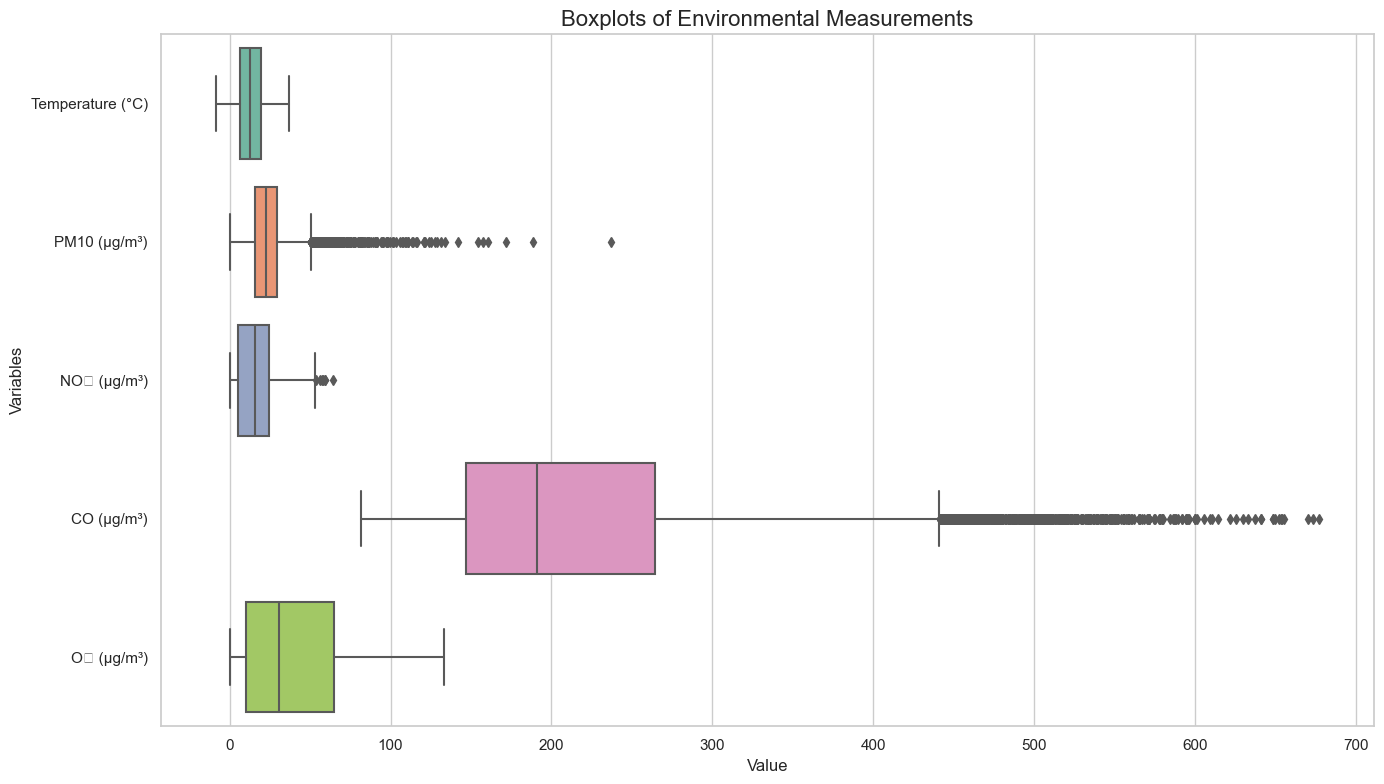

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better visuals
sns.set(style="whitegrid")

# Create a boxplot for each numeric column
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_1[numeric_cols], orient="h", palette="Set2")

plt.title("Boxplots of Environmental Measurements", fontsize=16)
plt.xlabel("Value")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

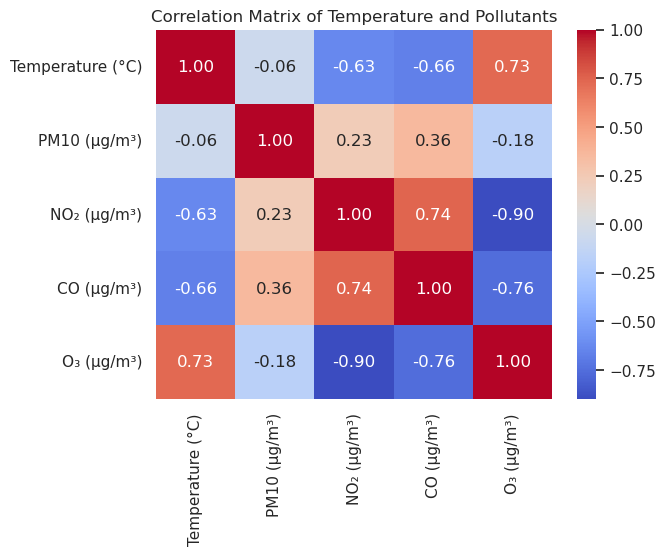

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

# Compute correlation matrix
corr_matrix = df_1.corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix of Temperature and Pollutants")
plt.show()

In [25]:
df_2 = df_1.copy()

In [26]:
print(df_2.columns.tolist())

['Temperature (°C)', 'PM10 (μg/m³)', 'NO₂ (μg/m³)', 'CO (μg/m³)', 'O₃ (μg/m³)']


In [27]:
from scipy.stats import pearsonr

temp_col = 'Temperature (°C)'  
pollutants = ['PM10 (μg/m³)', 'NO₂ (μg/m³)', 'CO (μg/m³)', 'O₃ (μg/m³)']

for pollutant in pollutants:
    temp_df = df_2[[temp_col, pollutant]].dropna() 
    r, p = pearsonr(temp_df[temp_col], temp_df[pollutant])
    print(f"Correlation between temperature and {pollutant}: r = {r:.3f}, p-value = {p:.3e}")

Correlation between temperature and PM10 (μg/m³): r = -0.065, p-value = 1.815e-20
Correlation between temperature and NO₂ (μg/m³): r = -0.628, p-value = 0.000e+00
Correlation between temperature and CO (μg/m³): r = -0.664, p-value = 0.000e+00
Correlation between temperature and O₃ (μg/m³): r = 0.729, p-value = 0.000e+00


In [28]:
import statsmodels.api as sm

temp_col = 'Temperature (°C)'  
pollutants = ['PM10 (μg/m³)', 'NO₂ (μg/m³)', 'CO (μg/m³)', 'O₃ (μg/m³)']

for pollutant in pollutants:
    # Always slice fresh data to avoid missing columns
    temp_df2 = df_2[[temp_col, pollutant]].dropna()

    # Define independent and dependent variables
    X = sm.add_constant(temp_df2[temp_col])  # Add intercept term (constant)
    y = temp_df2[pollutant]
    
    # Fit the linear regression model
    model = sm.OLS(y, X).fit()
    
    # Display regression results
    print(f"\n Regression results for {pollutant}:")
    print(model.summary())



📈 Regression results for PM10 (μg/m³):
                            OLS Regression Results                            
Dep. Variable:           PM10 (μg/m³)   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     86.17
Date:                Thu, 30 Oct 2025   Prob (F-statistic):           1.82e-20
Time:                        07:46:49   Log-Likelihood:                -80323.
No. Observations:               20456   AIC:                         1.606e+05
Df Residuals:                   20454   BIC:                         1.607e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------


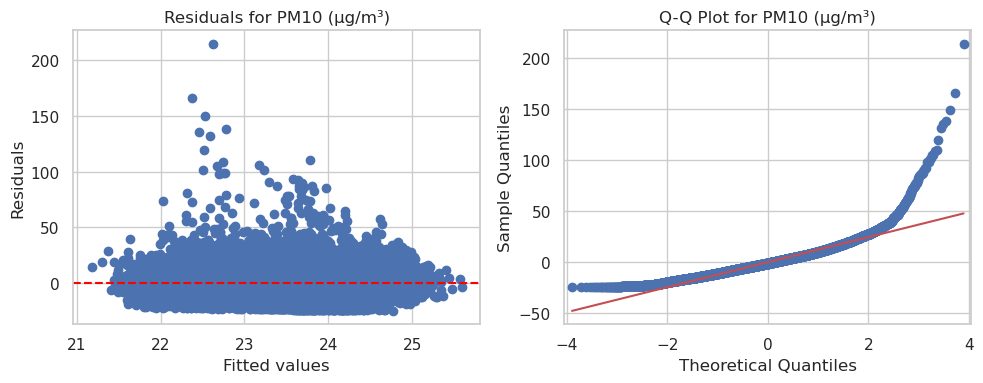

Durbin-Watson for PM10 (μg/m³): 0.321


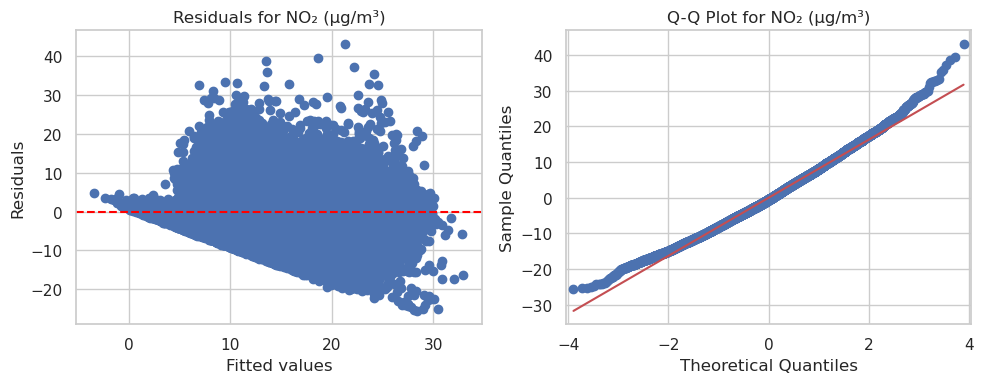

Durbin-Watson for NO₂ (μg/m³): 0.548


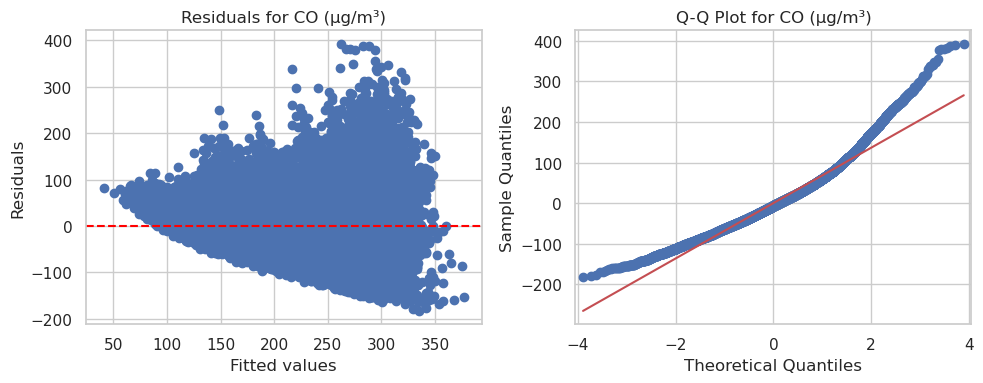

Durbin-Watson for CO (μg/m³): 0.347


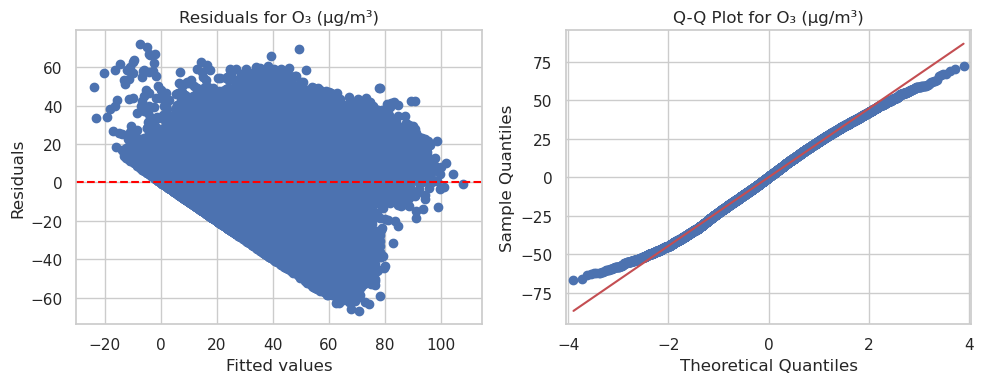

Durbin-Watson for O₃ (μg/m³): 0.639


In [29]:
for pollutant in pollutants:
    temp_df3 = df_2[[temp_col, pollutant]].dropna()
    X = sm.add_constant(temp_df3[temp_col])
    y = temp_df3[pollutant]
    model = sm.OLS(y, X).fit()
    residuals = model.resid

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(model.fittedvalues, residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    plt.title(f'Residuals for {pollutant}')

    plt.subplot(1,2,2)
    qqplot(residuals, line='s', ax=plt.gca())
    plt.title(f'Q-Q Plot for {pollutant}')
    plt.tight_layout()
    plt.show()

    dw = durbin_watson(residuals)
    print(f'Durbin-Watson for {pollutant}: {dw:.3f}')


### Feature Engineering

In [30]:
df_3 = df_2.copy()

In [31]:
# Required imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# =======================
# Step 0: Prepare df_3_eng
# =======================
df_3_eng = df_3.copy()

# Ensure index is DatetimeIndex
if not isinstance(df_3_eng.index, pd.DatetimeIndex):
    df_3_eng.index = pd.to_datetime(df_3_eng.index)

# Sort index for time series safety
df_3_eng = df_3_eng.sort_index()

# 🔥 CRITICAL: Remove duplicate columns (even if you think they're gone)
df_3_eng = df_3_eng.loc[:, ~df_3_eng.columns.duplicated()]
print(f"Columns after removing duplicates: {list(df_3_eng.columns)}")

# Double-check that key columns exist
required_cols = ['Temperature (°C)', 'NO₂ (μg/m³)', 'CO (μg/m³)', 'PM10 (μg/m³)', 'O₃ (μg/m³)']
for col in required_cols:
    if col not in df_3_eng.columns:
        raise KeyError(f"Missing required column: {col}")

# ============================
# Step 1: Polynomial Features
# ============================
poly_cols = ['Temperature (°C)', 'NO₂ (μg/m³)', 'CO (μg/m³)']
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df_3_eng[poly_cols])
poly_feature_names = poly.get_feature_names_out(poly_cols)

# Create DataFrame for polynomial features
poly_df = pd.DataFrame(poly_features, index=df_3_eng.index, columns=poly_feature_names)

# Concatenate safely
df_3_eng = pd.concat([df_3_eng, poly_df], axis=1)

# 🔁 Remove duplicates again after concat (just in case)
df_3_eng = df_3_eng.loc[:, ~df_3_eng.columns.duplicated()]

# =================================
# Step 2: Interaction Term (NO₂ × CO)
# =================================
# 🔍 Debug: Check what we're multiplying
no2_col = df_3_eng['NO₂ (μg/m³)']
co_col = df_3_eng['CO (μg/m³)']

# Ensure they are Series, not DataFrames
assert isinstance(no2_col, pd.Series), f"NO₂ column is {type(no2_col)}, not Series"
assert isinstance(co_col, pd.Series), f"CO column is {type(co_col)}, not Series"

# Safe multiplication using .values
product = no2_col.values * co_col.values  # This is 1D

# Now assign — this will work
df_3_eng['NO₂_CO'] = product
print("✅ Successfully added NO₂_CO interaction term")

# =================================
# Step 3: Lagged Variables
# =================================
df_3_eng['Temperature_lag1'] = df_3_eng['Temperature (°C)'].shift(1)
df_3_eng['PM10_lag1'] = df_3_eng['PM10 (μg/m³)'].shift(1)
df_3_eng['NO₂_lag1'] = df_3_eng['NO₂ (μg/m³)'].shift(1)
df_3_eng['O₃_lag1'] = df_3_eng['O₃ (μg/m³)'].shift(1)

# =================================
# Step 4: Seasonal Features
# =================================
df_3_eng['Month'] = df_3_eng.index.month
df_3_eng['sin_Month'] = np.sin(2 * np.pi * df_3_eng['Month'] / 12)
df_3_eng['cos_Month'] = np.cos(2 * np.pi * df_3_eng['Month'] / 12)
df_3_eng = df_3_eng.drop(columns=['Month'])

# =================================
# Step 5: Define Target & Features
# =================================
target = 'O₃ (μg/m³)'  # Change if needed

# Drop rows with NaN (from lags, etc.)
df_clean = df_3_eng.dropna()

if target not in df_clean.columns:
    raise KeyError(f"Target '{target}' not found in cleaned data")

X = df_clean.drop(columns=[target])
y = df_clean[target]

print(f"Feature matrix X shape: {X.shape}")
print(f"Target y shape: {y.shape}")

# =================================
# Step 6: Scaling
# =================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

# =================================
# Step 7: Feature Selection (RFE)
# =================================
n_features_to_select = 10
rfe = RFE(estimator=LinearRegression(), n_features_to_select=n_features_to_select)
rfe.fit(X_scaled_df, y)

# Get selected features
selected_features = X_scaled_df.columns[rfe.support_]
print("\n✅ Selected Features:")
print(list(selected_features))

# Final dataset
X_final = X_scaled_df.loc[:, rfe.support_]

Columns after removing duplicates: ['Temperature (°C)', 'PM10 (μg/m³)', 'NO₂ (μg/m³)', 'CO (μg/m³)', 'O₃ (μg/m³)']
✅ Successfully added NO₂_CO interaction term
Feature matrix X shape: (20455, 17)
Target y shape: (20455,)

✅ Selected Features:
['Temperature (°C)', 'NO₂ (μg/m³)', 'CO (μg/m³)', 'Temperature (°C)^2', 'Temperature (°C) NO₂ (μg/m³)', 'NO₂ (μg/m³)^2', 'CO (μg/m³)^2', 'Temperature_lag1', 'NO₂_lag1', 'O₃_lag1']
